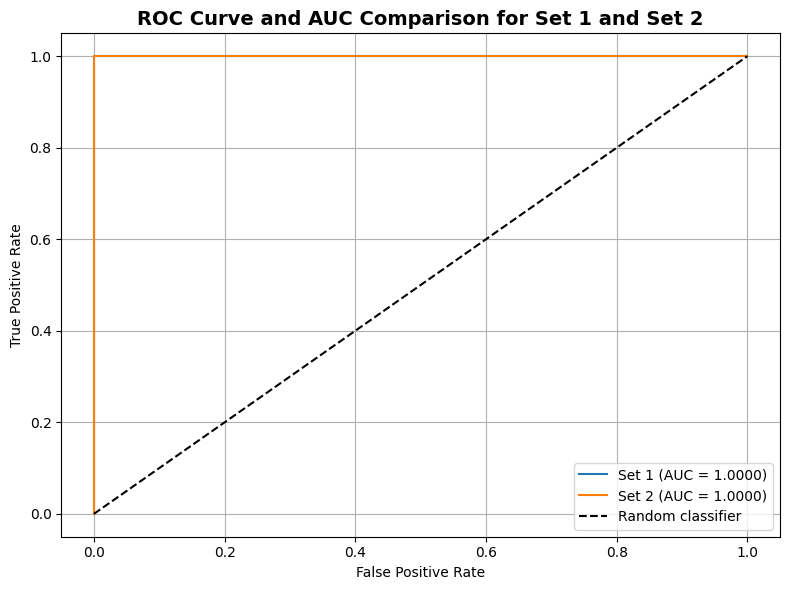

In [2]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Helper function to load .class data
def load_class_file(filepath):
    labels = []
    scores = []
    with open(filepath, 'r') as file:
        for line in file:
            parts = line.strip().split()
            labels.append(int(parts[1]))      # True label
            scores.append(float(parts[2]))    # E-value
    labels = np.array(labels)
    scores = -np.log10(np.array(scores))      # Convert e-values: lower e-value = higher confidence
    return labels, scores

# Load data
labels1, scores1 = load_class_file("set_1.class")
labels2, scores2 = load_class_file("set_2.class")

# Compute ROC curve and AUC for both sets
fpr1, tpr1, _ = roc_curve(labels1, scores1)
roc_auc1 = auc(fpr1, tpr1)

fpr2, tpr2, _ = roc_curve(labels2, scores2)
roc_auc2 = auc(fpr2, tpr2)

# Plot the ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label=f'Set 1 (AUC = {roc_auc1:.4f})')
plt.plot(fpr2, tpr2, label=f'Set 2 (AUC = {roc_auc2:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("ROC Curve and AUC Comparison for Set 1 and Set 2", fontsize=14, weight='bold')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()